### Unsupervised analysis

After preprocessing but before any supervised feature selection, we perform unsupervised 
analysis on the full dataset. Since the purpose is purely exploratory and cluster assignments 
are not used as inputs to any subsequent supervised model, there is no risk of data leakage 
in using the complete set of samples.

PCA is applied exclusively to the seven continuous features, as it assumes continuous inputs 
and would be distorted by the high proportion of one-hot encoded columns. The goal is to 
uncover the variance structure of the numerical variables, identify redundant or correlated 
features, and check whether the directions of maximum variance align with income as a 
supplementary variable.

K-Means and GMM clustering are also performed on the continuous features, for the same 
reasons. Cluster assignments are then profiled against the full feature set — including 
categorical variables and the income label — to assess whether the discovered structure 
maps onto meaningful socioeconomic groups.

### Setup and data imports

In [22]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42
DATA_DIR = Path(".")

# Plot configuration
PLOT_COLORS = {
    "neutral": "#2F80ED",
    "neutral_light": "#7DB7FF",
    "income_low": "#2F80ED",
    "income_high": "#FF8A00",
    "after": "#00B894",
    "outlier": "#E63946",
    "mild": "#F2C94C",
    "severe": "#E63946",
    "reference": "#4A5568",
}
TARGET_PALETTE_NUMERIC = {0: PLOT_COLORS["income_low"], 1: PLOT_COLORS["income_high"]}

sns.set_theme(
    style="whitegrid",
    palette=[PLOT_COLORS["neutral"], PLOT_COLORS["income_high"], PLOT_COLORS["after"], PLOT_COLORS["outlier"]],
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.edgecolor": "#D7DEE8",
        "axes.linewidth": 0.8,
        "grid.color": "#E8EDF3",
        "grid.linewidth": 0.7,
        "legend.frameon": False,
    },
)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlepad"] = 10


def polish_axes(ax, grid_axis="y"):
    ax.grid(False)
    ax.grid(True, axis=grid_axis, alpha=0.55)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)
    return ax

PROCESSED_FILES = {
    "X_train": DATA_DIR / "adult_X_train.csv",
    "X_test": DATA_DIR / "adult_X_test.csv",
    "y_train": DATA_DIR / "adult_y_train.csv",
    "y_test": DATA_DIR / "adult_y_test.csv",
    "preprocessor": DATA_DIR / "preprocessor.joblib",
}

missing_files = [name for name, path in PROCESSED_FILES.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing processed file(s): "
        + ", ".join(missing_files)
        + ". Run preprocessing_adult_census_BERTA.ipynb first."
    )

X_train = pd.read_csv(PROCESSED_FILES["X_train"], index_col=0)
X_test = pd.read_csv(PROCESSED_FILES["X_test"], index_col=0)
y_train = pd.read_csv(PROCESSED_FILES["y_train"], index_col=0).squeeze("columns")
y_test = pd.read_csv(PROCESSED_FILES["y_test"], index_col=0).squeeze("columns")
preprocessor = joblib.load(PROCESSED_FILES["preprocessor"])

X = pd.concat([X_train, X_test]).sort_index()
y = pd.concat([y_train, y_test]).sort_index()

analysis_df = X.copy()
analysis_df["income"] = y.loc[analysis_df.index]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
display(analysis_df.head())


X shape: (32561, 73)
y shape: (32561,)


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,...,cat__relationship_Wife,cat__race_Amer-Indian-Eskimo,cat__race_Asian-Pac-Islander,cat__race_Black,cat__race_Other,cat__race_White,cat__capital_direction_gain,cat__capital_direction_loss,cat__capital_direction_none,income
0,3.776660,-0.419226,-0.03412,-0.300842,5.031931,-1.797389,2.754749,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
1,3.189651,-0.419226,-1.81908,-0.300842,5.031931,-1.797389,-0.125426,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
2,2.015634,-0.031235,-0.03412,-0.300842,5.031931,-1.797389,1.452975,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
3,1.135121,-2.359179,-0.03412,-0.300842,4.962607,-1.630647,0.802088,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
4,0.181232,-0.031235,-0.03412,-0.300842,4.962607,-1.630647,0.096961,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0


### PCA

We first apply PCA to the six continuous features only (`age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`). This gives a theoretically cleaner decomposition, since PCA assumes continuous inputs. The `income` label is used only as a color label on the score plot afterwards - it does not influence the components, but lets us see whether the directions of maximum variance align with income.

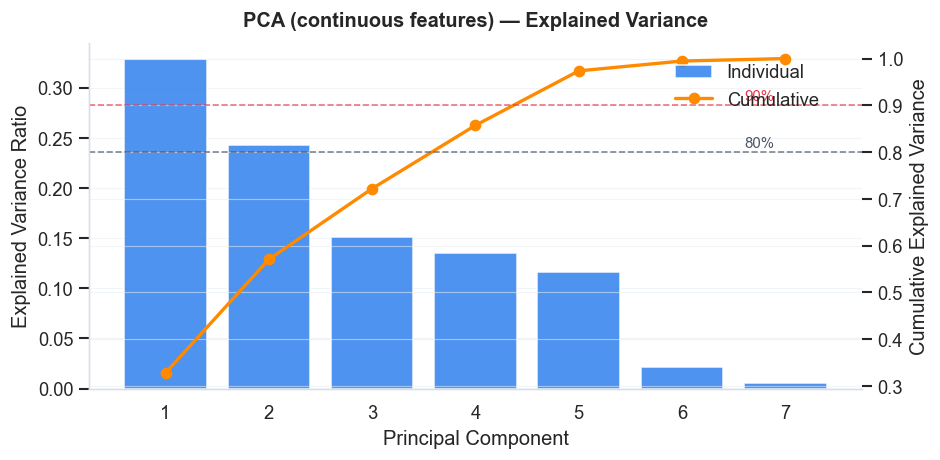

Components needed for 80% variance: 4
Components needed for 90% variance: 5


In [23]:
CONTINUOUS_COLS = [
    "num__age",
    "num__education_num",
    "num__hours_per_week",
    "num__capital_gain_log",
    "num__capital_loss_log",
    "num__net_capital",
    "num__age_x_hours",
]

X_cont = X[CONTINUOUS_COLS].values

pca_cont = PCA(random_state=RANDOM_STATE)
pca_cont.fit(X_cont)
X_cont_pca = pca_cont.transform(X_cont)

explained_cont = pca_cont.explained_variance_ratio_
cumulative_cont = np.cumsum(explained_cont)
n_cont = len(CONTINUOUS_COLS)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, n_cont + 1), explained_cont, color=PLOT_COLORS["neutral"], alpha=0.85, label="Individual")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()
ax2.plot(range(1, n_cont + 1), cumulative_cont, color=PLOT_COLORS["income_high"], marker="o", linewidth=2, label="Cumulative")
ax2.set_ylabel("Cumulative Explained Variance")
ax2.axhline(0.80, color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.0, alpha=0.7)
ax2.axhline(0.90, color=PLOT_COLORS["severe"], linestyle="--", linewidth=1.0, alpha=0.7)
ax2.text(n_cont - 0.4, 0.81, "80%", color=PLOT_COLORS["reference"], fontsize=9)
ax2.text(n_cont - 0.4, 0.91, "90%", color=PLOT_COLORS["severe"], fontsize=9)

polish_axes(ax1)
polish_axes(ax2)
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.title("PCA (continuous features) — Explained Variance")
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90]:
    n = np.argmax(cumulative_cont >= threshold) + 1
    print(f"Components needed for {int(threshold*100)}% variance: {n}")


The variance is notably spread across all seven components, with no single dominant axis —
PC1 explains ~33% and PC2 ~25%, and four components are needed to reach 80%. This suggests
the continuous features carry relatively independent information. We examine the loadings next
to understand which features drive each component and why the variance is distributed this way.

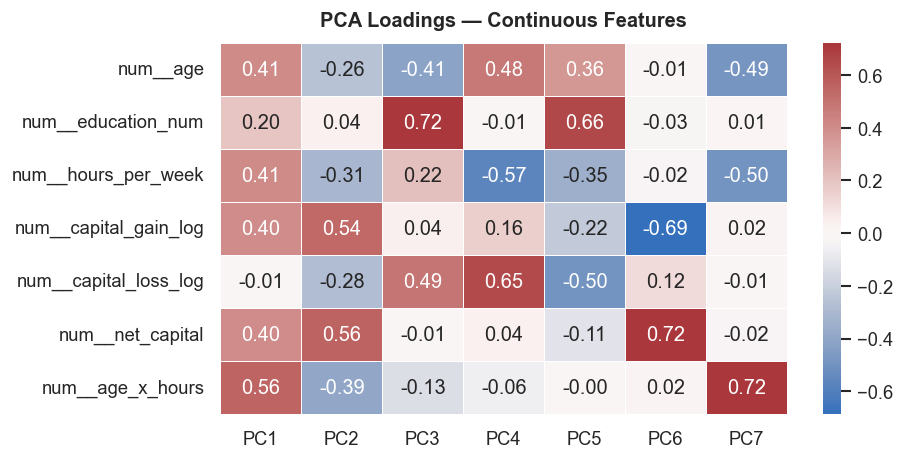

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
num__age,0.405,-0.261,-0.414,0.478,0.361,-0.014,-0.488
num__education_num,0.195,0.037,0.722,-0.014,0.662,-0.031,0.006
num__hours_per_week,0.406,-0.311,0.218,-0.568,-0.350,-0.021,-0.496
num__capital_gain_log,0.403,0.537,0.043,0.158,-0.225,-0.687,0.018
num__capital_loss_log,-0.006,-0.283,0.490,0.647,-0.498,0.116,-0.006
num__net_capital,0.401,0.559,-0.005,0.040,-0.109,0.716,-0.024
num__age_x_hours,0.557,-0.390,-0.133,-0.064,-0.004,0.019,0.718


In [24]:
loadings = pd.DataFrame(
    pca_cont.components_.T,
    index=CONTINUOUS_COLS,
    columns=[f"PC{i+1}" for i in range(n_cont)]
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    loadings, annot=True, fmt=".2f", cmap="vlag",
    center=0, linewidths=0.5, ax=ax
)
ax.set_title("PCA Loadings — Continuous Features")
plt.tight_layout()
plt.show()

display(loadings.round(3))


PC1 loads positively and fairly evenly on `age`, `hours_per_week`, `capital_gain_log`,
`net_capital`, and most strongly on `age_x_hours` (0.56). This component captures a general
**socioeconomic activity** dimension: older individuals who work longer hours and have capital
activity score high on PC1. The interaction term `age_x_hours` dominating this axis makes
sense: it was engineered precisely to capture this combined effect.

PC2 is driven by `capital_gain_log` (0.54) and `net_capital` (0.56), with a negative
contribution from `age_x_hours` (-0.39). This axis captures **capital activity independent
of work effort**: individuals with high capital gains but not necessarily high working hours.
It separates passive income from labor income.

PC3 and PC4 are dominated by `education_num` (0.72) and `capital_loss_log` (0.65)
respectively, confirming that education level and capital loss carry largely orthogonal
information to the first two components, which explains why variance is so spread out.

The spread of variance across components is therefore not noise but a reflection of the
dataset's genuine multidimensionality: age, education, work hours, and capital activity are
socioeconomically distinct dimensions that PCA cannot collapse into fewer axes without
significant information loss.

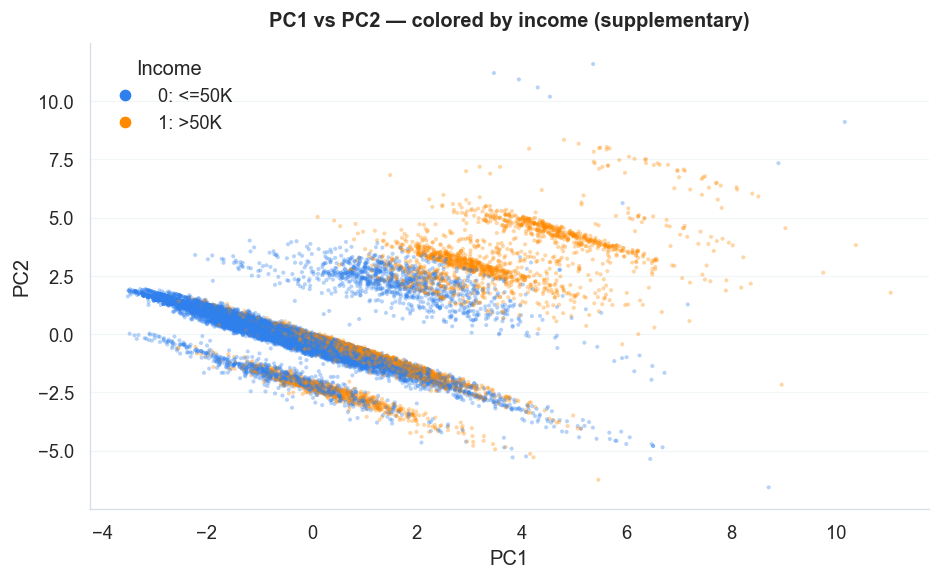

In [25]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 1],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PC1 vs PC2 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


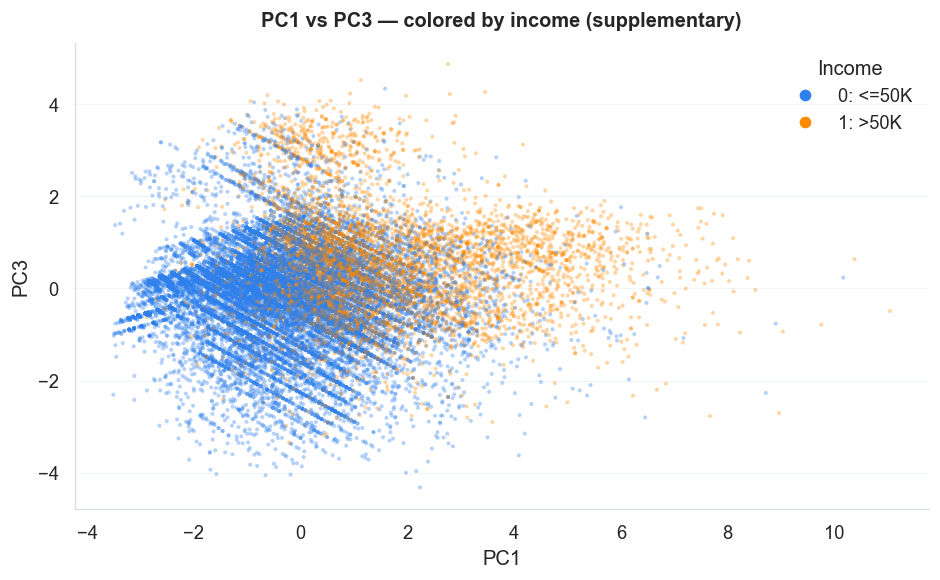

In [26]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 2],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC3")
ax.set_title("PC1 vs PC3 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


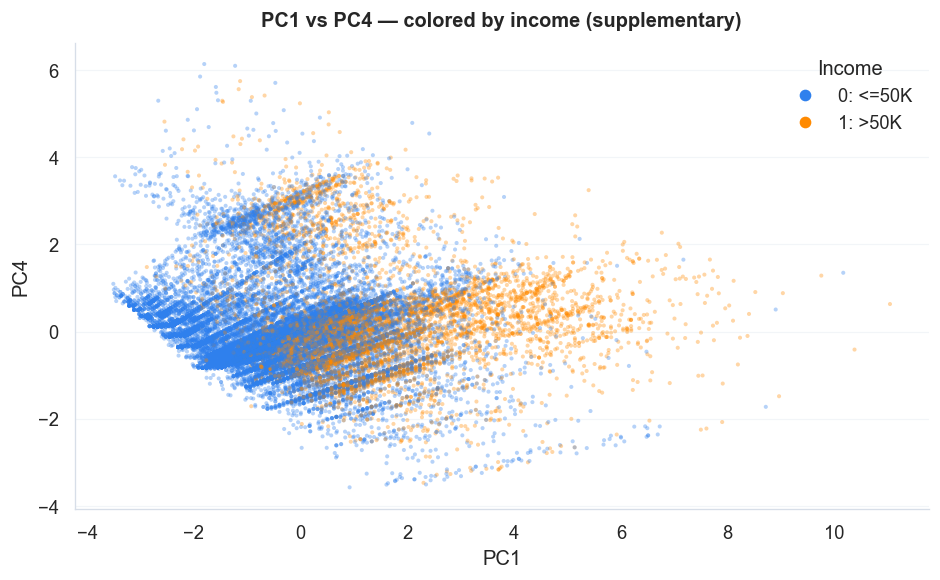

In [27]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC4")
ax.set_title("PC1 vs PC4 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


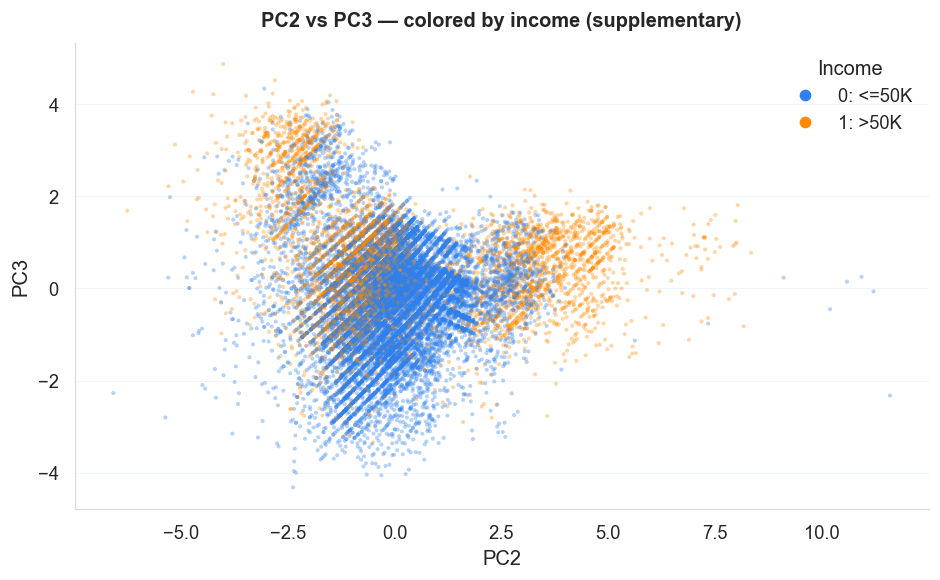

In [28]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 1], X_cont_pca[:, 2],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC2")
ax.set_ylabel("PC3")
ax.set_title("PC2 vs PC3 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


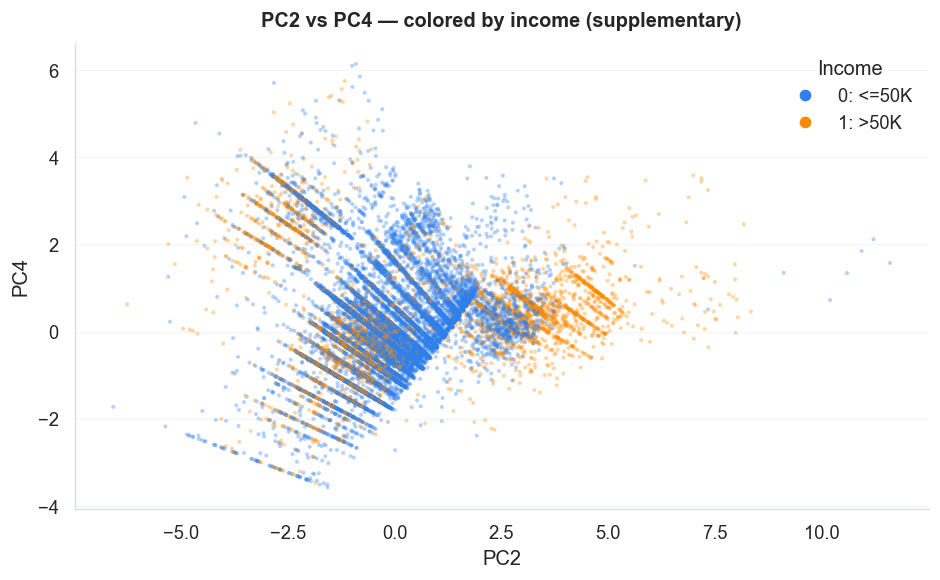

In [29]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 1], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC2")
ax.set_ylabel("PC4")
ax.set_title("PC2 vs PC4 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


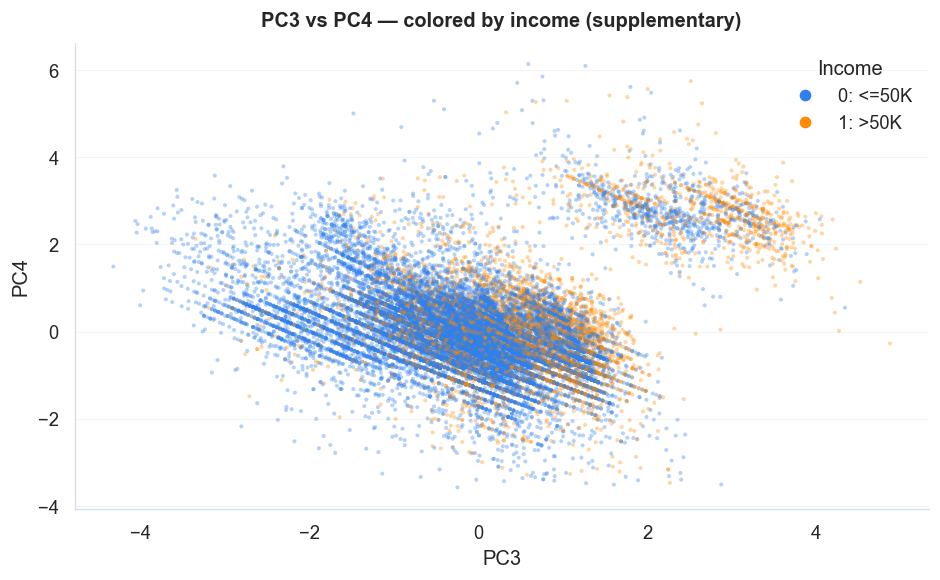

In [30]:
income_numeric = y.loc[X.index].values

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_cont_pca[:, 2], X_cont_pca[:, 3],
    c=[TARGET_PALETTE_NUMERIC[int(v)] for v in income_numeric], alpha=0.35, s=6, edgecolors="none"
)
ax.set_xlabel("PC3")
ax.set_ylabel("PC4")
ax.set_title("PC3 vs PC4 — colored by income (supplementary)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=color, label=label, markersize=6)
    for label, color in [("0: <=50K", TARGET_PALETTE_NUMERIC[0]), ("1: >50K", TARGET_PALETTE_NUMERIC[1])]
]
ax.legend(handles=handles, title="Income")
polish_axes(ax)
plt.tight_layout()
plt.show()


In [31]:
print(y.unique())
print(y.value_counts())

[0 1]
income
0    24720
1     7841
Name: count, dtype: int64


PC1 shows the clearest gradient with income across all plots: high PC1 values 
consistently correspond to the >50K class, confirming that the socioeconomic 
activity dimension (age, work hours, capital gains) is meaningfully aligned with 
income even though it was constructed without the label.

The parallel stripe pattern visible in several plots reflects the discrete nature 
of underlying features such as `education_num` and `hours_per_week`, which create 
natural bands in the PCA space.

Notably, the PC3 vs PC4 plot shows the clearest visual separation between income 
groups: two largely distinct clouds. Although these components explain less variance 
(~30% combined), they capture education level and capital activity direction, which 
are among the strongest individual predictors of income. This suggests that the 
directions of maximum variance do not always coincide with the most discriminative 
directions, a key limitation of PCA as an unsupervised method.

### K-Means Clustering

K-Means is applied to the same seven continuous features used for PCA. We try 
k = 2, 3, 4, 5, 6, 8, 10 and use the elbow method (inertia) and silhouette score 
to select the most appropriate number of clusters. Cluster assignments are then 
profiled against the full feature set to assess whether the discovered structure 
maps onto meaningful socioeconomic groups.

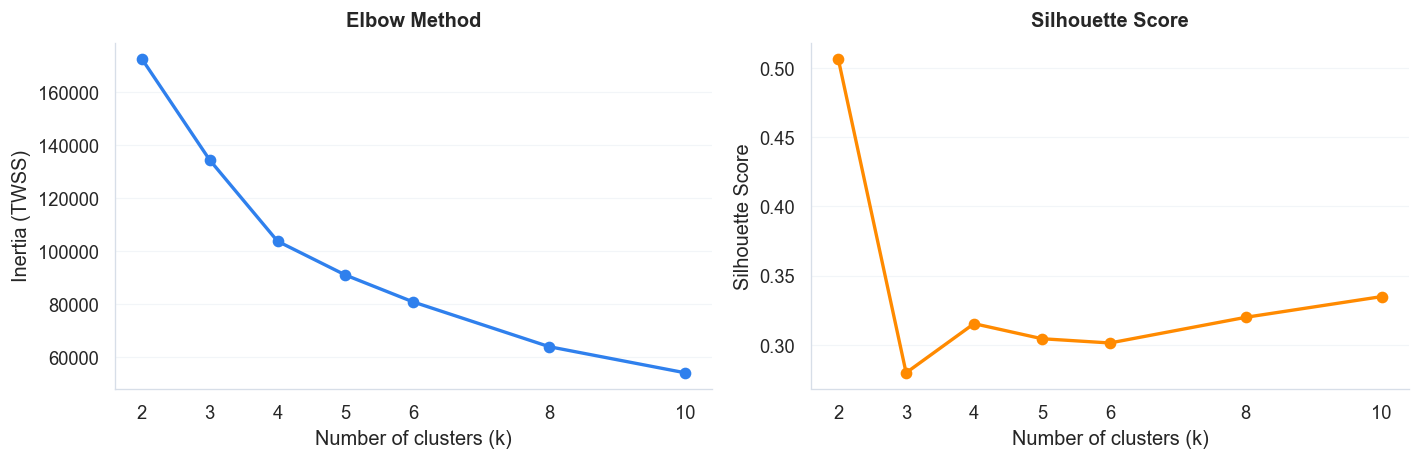

Silhouette scores:
  k=2: 0.5066
  k=3: 0.2798
  k=4: 0.3153
  k=5: 0.3044
  k=6: 0.3013
  k=8: 0.3198
  k=10: 0.3348


In [32]:
K_VALUES = [2, 3, 4, 5, 6, 8, 10]

inertias = []
silhouettes = []

for k in K_VALUES:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_cont)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cont, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K_VALUES, inertias, marker="o", color=PLOT_COLORS["neutral"], linewidth=2)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (TWSS)")
ax1.set_title("Elbow Method")
ax1.set_xticks(K_VALUES)
polish_axes(ax1)

ax2.plot(K_VALUES, silhouettes, marker="o", color=PLOT_COLORS["income_high"], linewidth=2)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score")
ax2.set_xticks(K_VALUES)
polish_axes(ax2)

plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, s in zip(K_VALUES, silhouettes):
    print(f"  k={k}: {s:.4f}")


The elbow curve shows a gradual decrease in inertia with no sharp bend, suggesting 
the continuous features do not form strongly separated natural clusters. A slight 
inflection is visible around k=4. The silhouette score peaks at k=2 (0.507) but 
drops sharply at k=3 and remains flat around 0.30–0.33 for higher values, indicating 
that beyond k=2 the clusters become less compact relative to their separation.

The two criteria do not fully agree. k=2 produces the most 
statistically cohesive partition but is too coarse to yield meaningful socioeconomic 
groups — it would likely reduce to a simple high vs. low capital activity split. We 
therefore select k=4, which corresponds to the slight elbow in the inertia curve and 
offers a better silhouette than k=3, while providing enough granularity for 
interpretable profiling.

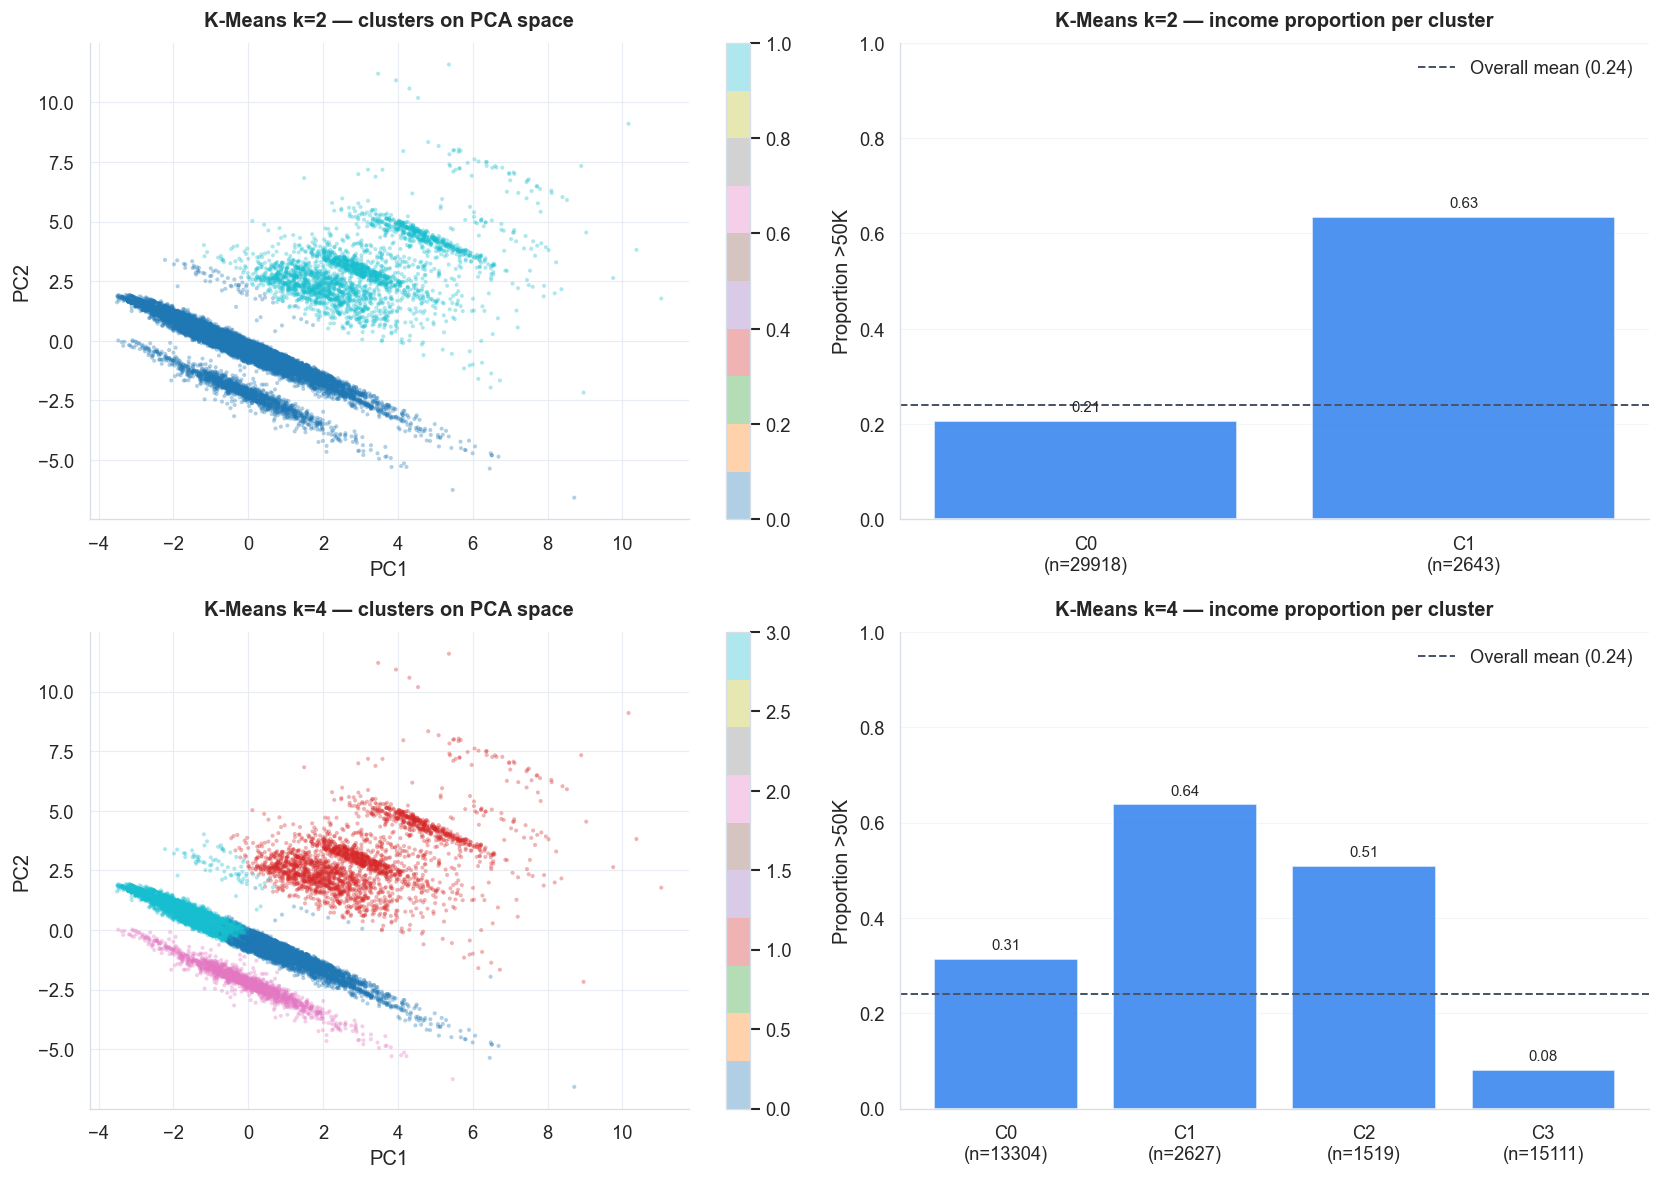

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, k in enumerate([2, 4]):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_cont)
    if k == 4:
        km_labels = labels
    
    # ── PC1 vs PC2 colored by cluster ────────────────────────────────────────
    ax = axes[idx, 0]
    scatter = ax.scatter(
        X_cont_pca[:, 0], X_cont_pca[:, 1],
        c=labels, cmap="tab10", alpha=0.35, s=6, edgecolors="none"
    )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"K-Means k={k} — clusters on PCA space")
    plt.colorbar(scatter, ax=ax)

    # ── Income proportion per cluster ─────────────────────────────────────────
    ax = axes[idx, 1]
    cluster_df = X[CONTINUOUS_COLS].copy()
    cluster_df["cluster"] = labels
    cluster_df["income"] = y.loc[X.index].values
    income_prop = cluster_df.groupby("cluster")["income"].mean()
    cluster_size = cluster_df.groupby("cluster")["income"].count()
    
    bars = ax.bar(
        [f"C{c}\n(n={cluster_size[c]})" for c in income_prop.index],
        income_prop.values,
        color=PLOT_COLORS["neutral"], alpha=0.85
    )
    ax.axhline(y.mean(), color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.2, label=f"Overall mean ({y.mean():.2f})")
    ax.set_ylabel("Proportion >50K")
    ax.set_title(f"K-Means k={k} — income proportion per cluster")
    ax.set_ylim(0, 1)
    ax.legend()
    polish_axes(ax)
    
    # Add proportion labels on bars
    for bar, val in zip(bars, income_prop.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


K-Means with k=2 isolates a very small group (n=2,643, ~8% of the data) with a high 
proportion of >50K earners (63%), while the remaining 92% of individuals fall into a 
single large cluster with only 21% >50K. This suggests that the most natural binary 
split in the continuous feature space is not a broad high vs. low income division, but 
rather the separation of a small subgroup with significant capital activity from 
everyone else. While informative, this partition is too coarse for meaningful 
socioeconomic profiling.

k=4 provides a much richer structure. The four clusters show a clear income gradient: 
from C3 (8% >50K, n=15,111) to C0 (31%), C2 (51%) and C1 (64%, n=2,627). This 
suggests that the continuous features — age, education, work hours and capital activity 
— naturally stratify individuals into groups with meaningfully different income profiles, 
even though income was not used to construct the clusters. We therefore proceed with 
k=4 for profiling.

In [34]:
cluster_df = X[CONTINUOUS_COLS].copy()
cluster_df["cluster"] = labels
cluster_df["income"] = y.loc[X.index].values

cluster_df.head()

,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,cluster,income
0,3.776660,-0.419226,-0.03412,-0.300842,5.031931,-1.797389,2.754749,2,0
1,3.189651,-0.419226,-1.81908,-0.300842,5.031931,-1.797389,-0.125426,2,0
2,2.015634,-0.031235,-0.03412,-0.300842,5.031931,-1.797389,1.452975,2,0
3,1.135121,-2.359179,-0.03412,-0.300842,4.962607,-1.630647,0.802088,2,0
4,0.181232,-0.031235,-0.03412,-0.300842,4.962607,-1.630647,0.096961,2,0


In [35]:
cluster_means = cluster_df.groupby("cluster")[CONTINUOUS_COLS].mean().round(3)
global_means = cluster_df[CONTINUOUS_COLS].mean().round(3)

# Add global mean as a row for comparison
profile_table = cluster_means.copy()
profile_table.loc["global"] = global_means
profile_table.index = [f"Cluster {i}" for i in range(4)] + ["Global mean"]

# Add cluster size and income proportion
summary = cluster_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Cluster {i}" for i in range(4)]
summary.loc["Global mean"] = [len(cluster_df), y.mean().round(3)]

final_table = pd.concat([summary, profile_table], axis=1)
display(final_table)

,size,income_prop,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Cluster 0,13304.0,0.314,0.686,0.072,0.418,-0.299,-0.223,-0.204,0.755
Cluster 1,2627.0,0.638,0.438,0.414,0.294,3.320,-0.223,2.693,0.498
Cluster 2,1519.0,0.509,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Cluster 3,15111.0,0.081,-0.696,-0.170,-0.439,-0.287,-0.223,-0.203,-0.775
Global mean,32561.0,0.241,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004


The numeric profiling reveals four socioeconomically distinct groups:

- **Cluster 3** (n=15,111, 8% >50K): the largest group, consistently below the global 
mean on all features — youngest, least educated, fewest hours worked, and no capital 
activity. This is the low-income majority.

- **Cluster 0** (n=13,304, 31% >50K): older individuals (age=0.69 vs global≈0) who 
work long hours (age_x_hours=0.75), but with no significant capital activity. This 
group represents experienced workers with moderate income prospects.

- **Cluster 2** (n=1,519, 51% >50K): defined almost entirely by high capital losses 
(capital_loss_log=4.49) and negative net capital (-0.89). Despite financial losses, 
over half earn >50K — suggesting these are financially active individuals who engage 
in investment activity, even at a loss.

- **Cluster 1** (n=2,627, 64% >50K): the smallest but highest-income group, 
characterised by very high capital gains (3.32) and net capital (2.69). This is the 
capital-wealthy group already identified in the k=2 analysis.

Together the clusters suggest that capital activity — both gains and losses — is a 
strong differentiator of income, even more so than age or education in isolation. 
We now profile the clusters against the categorical features to enrich this picture.

In [36]:
# ── Add cluster labels to full feature matrix ────────────────────────────────
profile_df = X.copy()
profile_df["cluster"] = km_labels
profile_df["income"] = y.values

# ── 1. Binary engineered features ────────────────────────────────────────────
bin_cols = [c for c in X.columns if c.startswith("bin__")]
bin_profile = profile_df.groupby("cluster")[bin_cols].mean().round(3)
bin_profile.loc["Global"] = profile_df[bin_cols].mean().round(3)
bin_profile.index = [f"Cluster {i}" for i in range(4)] + ["Global"]

print("Binary features — proportion per cluster:")
display(bin_profile)

# ── 2. Categorical features — most dominant category per cluster ──────────────
cat_groups = {
    "workclass": [c for c in X.columns if c.startswith("cat__workclass")],
    "education": [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation": [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship": [c for c in X.columns if c.startswith("cat__relationship")],
    "race": [c for c in X.columns if c.startswith("cat__race")],
}

for var_name, cols in cat_groups.items():
    # For each cluster, get proportion of each category and show top 3
    cluster_props = profile_df.groupby("cluster")[cols].mean().round(3)
    cluster_props.columns = [c.split("__")[-1] for c in cols]  # clean column names
    cluster_props.loc["Global"] = profile_df[cols].mean().round(3).values
    cluster_props.index = [f"Cluster {i}" for i in range(4)] + ["Global"]
    
    print(f"\n{var_name} — proportion per cluster (top 3 per cluster):")
    # Show only top 3 categories per cluster for readability
    top_cols = cluster_props.iloc[:4].max().nlargest(3).index
    display(cluster_props[top_cols])

Binary features — proportion per cluster:


,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
Cluster 0,0.728,0.000,0.001,0.287,0.920
Cluster 1,0.778,0.061,1.000,0.429,0.928
Cluster 2,0.757,0.000,1.000,0.398,0.930
Cluster 3,0.589,0.000,0.005,0.166,0.901
Global,0.669,0.005,0.130,0.248,0.912



workclass — proportion per cluster (top 3 per cluster):


,workclass_Private,workclass_Self-emp-not-inc,workclass_Local-gov
Cluster 0,0.637,0.108,0.080
Cluster 1,0.637,0.099,0.071
Cluster 2,0.646,0.100,0.084
Cluster 3,0.765,0.046,0.048
Global,0.697,0.078,0.064



education — proportion per cluster (top 3 per cluster):


...

,occupation_Exec-managerial,occupation_Prof-specialty,occupation_Other-service
Cluster 0,0.162,0.144,0.071
Cluster 1,0.209,0.209,0.033
Cluster 2,0.194,0.194,0.045
Cluster 3,0.071,0.091,0.145
Global,0.125,0.127,0.101



relationship — proportion per cluster (top 3 per cluster):


,relationship_Husband,relationship_Own-child,relationship_Not-in-family
Cluster 0,0.548,0.031,0.249
Cluster 1,0.606,0.037,0.202
Cluster 2,0.564,0.076,0.220
Cluster 3,0.228,0.294,0.273
Global,0.405,0.156,0.255



race — proportion per cluster (top 3 per cluster):


,race_White,race_Black,race_Asian-Pac-Islander
Cluster 0,0.867,0.088,0.030
Cluster 1,0.891,0.065,0.031
Cluster 2,0.886,0.068,0.036
Cluster 3,0.833,0.111,0.034
Global,0.854,0.096,0.032


The categorical profiling enriches the numeric picture considerably:

- **Cluster 3** (8% >50K) — *Young, single, low-income workers*: the youngest group 
with the lowest education (34% HS-grad), mostly never-married (55%) and frequently 
in the own-child relationship role (29%). Predominantly private sector with a higher 
share of service occupations. The least male cluster (59%).

- **Cluster 0** (31% >50K) — *Older working-class married men*: older individuals 
working long hours but with no capital activity. Mostly married (59%), husbands (55%), 
HS-grad educated, private sector. A large, moderately educated working group with 
stable but not high income.

- **Cluster 1** (64% >50K) — *Capital-wealthy professionals*: 100% have capital 
activity, with 6% hitting the maximum capital gain of 99,999. The most educated group 
(43% higher education), with the highest share of exec-managerial and professional 
occupations (21% each). Predominantly married husbands. This is the high-income 
professional and investor class.

- **Cluster 2** (51% >50K) — *Financially active with capital losses*: also 100% 
capital activity but defined by losses rather than gains, resulting in negative net 
capital. Similar education and occupation profile to Cluster 1 but with lower income 
alignment. These appear to be financially engaged individuals — likely investors — who 
happened to incur losses in the reference year.

Race does not meaningfully differentiate the clusters, with distributions remaining 
close to the global proportions across all four groups. This suggests that the 
continuous features driving the clustering do not strongly partition along racial lines.

### Gaussian Mixture Models (GMM)

GMM is applied to the same continuous feature space as K-Means. Unlike K-Means, GMM 
assumes the data is generated from a mixture of Gaussian distributions and assigns 
each point a probability of belonging to each component rather than a hard label. 
This makes it more flexible, particularly for clusters of different shapes and sizes.

We try n_components = 2, 3, 4, 5, 6, 8, 10 and compare three covariance types: 
`diag` (each component has its own diagonal covariance), `tied` (all components share 
the same covariance), and `full` (each component has its own full covariance matrix). 
Model selection is based on BIC and AIC.

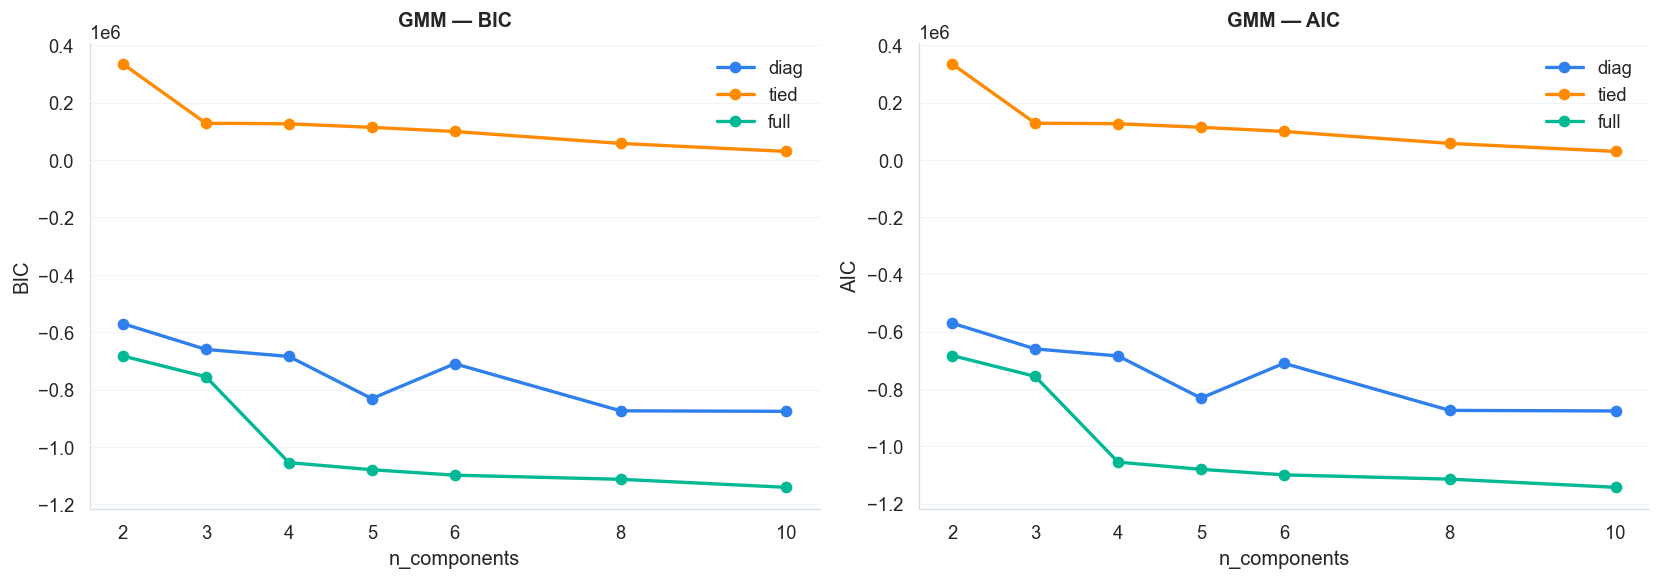

Best model per covariance type (lowest BIC):


,covariance_type,n_components,BIC,AIC
6,diag,10,-8.755533e+05,-8.768036e+05
20,full,10,-1.140426e+06,-1.143438e+06
13,tied,10,3.021545e+04,2.931763e+04


In [37]:
from sklearn.mixture import GaussianMixture

N_COMPONENTS = [2, 3, 4, 5, 6, 8, 10]
COV_TYPES = ["diag", "tied", "full"]

results = []
for cov in COV_TYPES:
    for n in N_COMPONENTS:
        gmm = GaussianMixture(
            n_components=n, covariance_type=cov,
            random_state=RANDOM_STATE, max_iter=200
        )
        gmm.fit(X_cont)
        results.append({
            "covariance_type": cov,
            "n_components": n,
            "BIC": gmm.bic(X_cont),
            "AIC": gmm.aic(X_cont)
        })

results_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for cov in COV_TYPES:
    subset = results_df[results_df["covariance_type"] == cov]
    ax1.plot(subset["n_components"], subset["BIC"], marker="o", linewidth=2, label=cov)
    ax2.plot(subset["n_components"], subset["AIC"], marker="o", linewidth=2, label=cov)

ax1.set_title("GMM — BIC")
ax1.set_xlabel("n_components")
ax1.set_ylabel("BIC")
ax1.set_xticks(N_COMPONENTS)
ax1.legend()
polish_axes(ax1)

ax2.set_title("GMM — AIC")
ax2.set_xlabel("n_components")
ax2.set_ylabel("AIC")
ax2.set_xticks(N_COMPONENTS)
ax2.legend()
polish_axes(ax2)

plt.tight_layout()
plt.show()

# Print best model per covariance type
print("Best model per covariance type (lowest BIC):")
display(results_df.loc[results_df.groupby("covariance_type")["BIC"].idxmin()])


The `tied` covariance type performs dramatically worse than the others (positive 
BIC/AIC), indicating that a shared covariance matrix across all components is too 
restrictive for this data. The `full` covariance type consistently outperforms `diag`, 
suggesting that the clusters have genuinely different shapes and orientations rather 
than just different scales.

Both `full` and `diag` improve continuously with n_components, with no sharp elbow. 
However, the `full` curve flattens noticeably after n=6, offering diminishing returns 
beyond that point. We therefore select `full` covariance with n=6 as the best balance 
between model fit and interpretability.

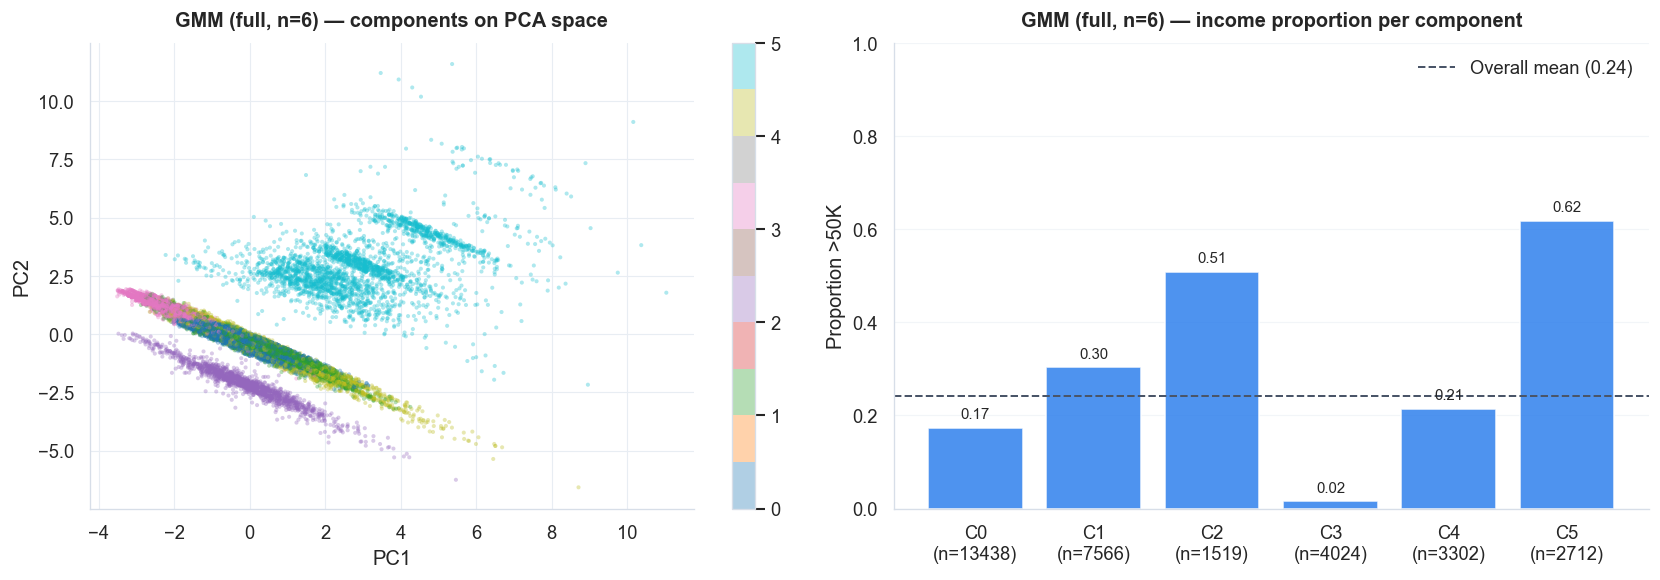

,size,income_prop,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Component 0,13438.0,0.173,-0.034,-0.117,-0.034,-0.301,-0.223,-0.205,-0.062
Component 1,7566.0,0.303,-0.097,0.223,0.660,-0.301,-0.223,-0.205,0.321
Component 2,1519.0,0.509,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Component 3,4024.0,0.016,-1.222,-0.225,-1.025,-0.301,-0.223,-0.205,-1.291
Component 4,3302.0,0.214,1.451,-0.233,-0.422,-0.301,-0.223,-0.205,0.611
Component 5,2712.0,0.618,0.403,0.382,0.251,3.293,-0.223,2.613,0.450
Global mean,32561.0,0.241,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004


In [38]:
# ── Fit final GMM ────────────────────────────────────────────────────────────
gmm_final = GaussianMixture(
    n_components=6, covariance_type="full",
    random_state=RANDOM_STATE, max_iter=200
)
gmm_final.fit(X_cont)
gmm_labels = gmm_final.predict(X_cont)
gmm_probs = gmm_final.predict_proba(X_cont)

gmm_df = X[CONTINUOUS_COLS].copy()
gmm_df["cluster"] = gmm_labels
gmm_df["income"] = y.values

# ── 1. PC1 vs PC2 colored by GMM component ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

scatter = ax1.scatter(
    X_cont_pca[:, 0], X_cont_pca[:, 1],
    c=gmm_labels, cmap="tab10", alpha=0.35, s=6, edgecolors="none"
)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("GMM (full, n=6) — components on PCA space")
plt.colorbar(scatter, ax=ax1)

# ── 2. Income proportion per component ───────────────────────────────────────
income_prop = gmm_df.groupby("cluster")["income"].mean()
cluster_size = gmm_df.groupby("cluster")["income"].count()

bars = ax2.bar(
    [f"C{c}\n(n={cluster_size[c]})" for c in income_prop.index],
    income_prop.values,
    color=PLOT_COLORS["neutral"], alpha=0.85
)
ax2.axhline(y.mean(), color=PLOT_COLORS["reference"], linestyle="--", linewidth=1.2,
            label=f"Overall mean ({y.mean():.2f})")
ax2.set_ylabel("Proportion >50K")
ax2.set_title("GMM (full, n=6) — income proportion per component")
ax2.set_ylim(0, 1)
ax2.legend()
polish_axes(ax2)

for bar, val in zip(bars, income_prop.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── 3. Numeric profiling ──────────────────────────────────────────────────────
cluster_means = gmm_df.groupby("cluster")[CONTINUOUS_COLS].mean().round(3)
global_means = gmm_df[CONTINUOUS_COLS].mean().round(3)
profile_table = cluster_means.copy()
profile_table.loc["Global"] = global_means
profile_table.index = [f"Component {i}" for i in range(6)] + ["Global mean"]

summary = gmm_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Component {i}" for i in range(6)]
summary.loc["Global mean"] = [len(gmm_df), y.mean().round(3)]

final_table = pd.concat([summary, profile_table], axis=1)
display(final_table)


GMM with full covariance and n=6 recovers a more granular structure than K-Means k=4, 
while confirming its core findings. The capital activity components are reproduced 
almost identically: Component 5 (62% >50K) corresponds to the capital gains group and 
Component 2 (51% >50K) to the capital losses group, with nearly identical numeric 
profiles to the K-Means equivalents.

The main added value of GMM is the finer decomposition of the low-to-moderate income 
population. K-Means cluster 3 (young, low-income) is split into two distinct groups: 
Component 3 (2% >50K), which captures extremely young part-time workers with very few 
hours, and Component 0 (17% >50K), the baseline low-income full-time worker close to 
the global mean on all features. Similarly, the older working group is split into 
Component 1 (30% >50K), defined by long working hours and moderate education, and 
Component 4 (21% >50K), the oldest subgroup with low capital activity — likely 
near-retirement individuals.

Overall, GMM confirms that capital activity is the strongest differentiator of high 
income, while providing a more nuanced view of the low-to-moderate income population 
by separating age and hours-worked effects that K-Means merged into a single cluster.

In [39]:
# ── Categorical profiling for GMM ────────────────────────────────────────────
gmm_profile_df = X.copy()
gmm_profile_df["cluster"] = gmm_labels
gmm_profile_df["income"] = y.values

# ── 1. Binary engineered features ────────────────────────────────────────────
bin_cols = [c for c in X.columns if c.startswith("bin__")]
bin_profile = gmm_profile_df.groupby("cluster")[bin_cols].mean().round(3)
bin_profile.loc["Global"] = gmm_profile_df[bin_cols].mean().round(3)
bin_profile.index = [f"Component {i}" for i in range(6)] + ["Global"]

print("Binary features — proportion per component:")
display(bin_profile)

# ── 2. Categorical features ───────────────────────────────────────────────────
cat_groups = {
    "workclass": [c for c in X.columns if c.startswith("cat__workclass")],
    "education": [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation": [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship": [c for c in X.columns if c.startswith("cat__relationship")],
    "race": [c for c in X.columns if c.startswith("cat__race")],
}

for var_name, cols in cat_groups.items():
    cluster_props = gmm_profile_df.groupby("cluster")[cols].mean().round(3)
    cluster_props.columns = [c.split("__")[-1] for c in cols]
    cluster_props.loc["Global"] = gmm_profile_df[cols].mean().round(3).values
    cluster_props.index = [f"Component {i}" for i in range(6)] + ["Global"]
    
    top_cols = cluster_props.iloc[:6].max().nlargest(3).index
    print(f"\n{var_name} — proportion per component (top 3):")
    display(cluster_props[top_cols])

Binary features — proportion per component:


,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
Component 0,0.665,0.000,0.00,0.197,0.896
Component 1,0.732,0.000,0.00,0.331,0.923
Component 2,0.757,0.000,1.00,0.398,0.930
Component 3,0.503,0.000,0.00,0.118,0.924
Component 4,0.625,0.000,0.00,0.214,0.921
Component 5,0.770,0.059,1.00,0.417,0.929
Global,0.669,0.005,0.13,0.248,0.912



workclass — proportion per component (top 3):


,workclass_Private,workclass_Self-emp-not-inc,workclass_Unknown
Component 0,0.739,0.042,0.046
Component 1,0.685,0.114,0.025
Component 2,0.646,0.100,0.038
Component 3,0.778,0.026,0.106
Component 4,0.526,0.181,0.125
Component 5,0.639,0.096,0.045
Global,0.697,0.078,0.056



education — proportion per component (top 3):


...

,occupation_Other-service,occupation_Prof-specialty,occupation_Exec-managerial
Component 0,0.091,0.104,0.103
Component 1,0.074,0.160,0.171
Component 2,0.045,0.194,0.194
Component 3,0.227,0.074,0.036
Component 4,0.131,0.119,0.120
Component 5,0.038,0.205,0.204
Global,0.101,0.127,0.125



relationship — proportion per component (top 3):


,relationship_Husband,relationship_Own-child,relationship_Not-in-family
Component 0,0.391,0.149,0.258
Component 1,0.484,0.061,0.272
Component 2,0.564,0.076,0.220
Component 3,0.059,0.565,0.232
Component 4,0.481,0.019,0.292
Component 5,0.589,0.052,0.201
Global,0.405,0.156,0.255



race — proportion per component (top 3):


,race_White,race_Black,race_Asian-Pac-Islander
Component 0,0.821,0.121,0.037
Component 1,0.886,0.072,0.027
Component 2,0.886,0.068,0.036
Component 3,0.851,0.095,0.034
Component 4,0.879,0.086,0.022
Component 5,0.888,0.067,0.031
Global,0.854,0.096,0.032


The categorical profiling confirms and enriches the numeric interpretation of each 
component:

- **Component 3** (2% >50K) — *Young single students/part-time workers*: almost 
entirely never-married (85%), predominantly in the own-child relationship role (57%), 
highest share of service occupations (23%), lowest education, and the least male 
component (50%). This is clearly a young, dependent, pre-career group.

- **Component 0** (17% >50K) — *Low-income general workers*: the most generic 
profile, close to global proportions on most variables. Mostly private sector (74%), 
HS-grad educated (37%), mix of married and never-married. No distinguishing 
categorical signal — this is the heterogeneous baseline group.

- **Component 4** (21% >50K) — *Older workers approaching retirement*: the oldest 
group numerically, with the highest share of self-employed (18%) and unknown workclass 
(13%), mostly married (55%), low education (35% HS-grad). The high self-employment 
rate is consistent with older individuals who have left traditional employment.

- **Component 1** (30% >50K) — *Hardworking moderate-income employees*: works the 
most hours, mostly private sector (69%), higher share of Bachelors (22%) and 
exec/professional occupations than Components 0 and 3. Mostly married husbands (48%).

- **Component 2** (51% >50K) — *Financially active, capital losses*: identical 
profile to K-Means Cluster 2 — 100% capital activity, mostly married (63%), 
professional/exec occupations (19% each). Financially engaged individuals incurring 
investment losses.

- **Component 5** (62% >50K) — *Capital-wealthy professionals*: 100% capital 
activity, 6% with maximum capital gain, most educated (42% higher education), highest 
share of exec/professional occupations (20% each), predominantly married husbands 
(59%). The high-income investor and professional class.

As with K-Means, race does not meaningfully differentiate components, remaining close 
to global proportions across all groups.

In [40]:
# ── Install kmodes if needed ─────────────────────────────────────────────────
!pip install kmodes

from kmodes.kprototypes import KPrototypes

# ── Reconstruct original categorical columns from one-hot ────────────────────
cat_reconstruct = {
    "workclass":      [c for c in X.columns if c.startswith("cat__workclass")],
    "education":      [c for c in X.columns if c.startswith("cat__education_") and "num" not in c],
    "marital_status": [c for c in X.columns if c.startswith("cat__marital")],
    "occupation":     [c for c in X.columns if c.startswith("cat__occupation")],
    "relationship":   [c for c in X.columns if c.startswith("cat__relationship")],
    "race":           [c for c in X.columns if c.startswith("cat__race")],
    "capital_direction": [c for c in X.columns if c.startswith("cat__capital_direction")],
}

df_mixed = X[CONTINUOUS_COLS].copy()

for var_name, cols in cat_reconstruct.items():
    df_mixed[var_name] = X[cols].idxmax(axis=1).str.split("__").str[-1]

# Add binary columns as categorical too
bin_cols = [c for c in X.columns if c.startswith("bin__")]
for col in bin_cols:
    df_mixed[col] = X[col].astype(str)

cat_col_names = list(cat_reconstruct.keys()) + bin_cols
num_col_names = CONTINUOUS_COLS

# K-Prototypes needs categorical columns at the end
# and the indices of categorical columns
cols_ordered = num_col_names + cat_col_names
df_kproto = df_mixed[cols_ordered].copy()
cat_indices = list(range(len(num_col_names), len(cols_ordered)))

print(f"Numeric columns: {len(num_col_names)}")
print(f"Categorical columns: {len(cat_col_names)}")
print(f"Total: {df_kproto.shape[1]}")
display(df_kproto.head(3))


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Numeric columns: 7
Categorical columns: 12
Total: 19


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours,workclass,education,marital_status,occupation,relationship,race,capital_direction,bin__sex,bin__capital_gain_is_99999,bin__has_capital_activity,bin__is_higher_education,bin__is_US
0,3.776660,-0.419226,-0.03412,-0.300842,5.031931,-1.797389,2.754749,workclass_Unknown,education_HS-grad,marital_status_Widowed,occupation_Unknown,relationship_Not-in-family,race_White,capital_direction_loss,0.0,0.0,1.0,0.0,1.0
1,3.189651,-0.419226,-1.81908,-0.300842,5.031931,-1.797389,-0.125426,workclass_Private,education_HS-grad,marital_status_Widowed,occupation_Exec-managerial,relationship_Not-in-family,race_White,capital_direction_loss,0.0,0.0,1.0,0.0,1.0
2,2.015634,-0.031235,-0.03412,-0.300842,5.031931,-1.797389,1.452975,workclass_Unknown,education_Some-college,marital_status_Widowed,occupation_Unknown,relationship_Unmarried,race_Black,capital_direction_loss,0.0,0.0,1.0,0.0,1.0


### K-Prototypes Clustering (Bonus)

K-Means and GMM were applied exclusively to the continuous features due to the 
limitations of distance-based methods on one-hot encoded data. As a complementary 
analysis, we apply K-Prototypes — an extension of K-Means designed for mixed data 
— which handles numerical and categorical variables jointly without requiring 
one-hot encoding. This allows us to assess whether incorporating categorical 
information (occupation, marital status, relationship, education, etc.) changes 
the cluster structure found previously.

The categorical columns are reconstructed from their one-hot encoded versions for 
this analysis only and are not used in any other part of the pipeline.

Fitting k=2...
  cost=245982
Fitting k=3...
  cost=194320
Fitting k=4...
  cost=162036
Fitting k=5...
  cost=145258
Fitting k=6...
  cost=134613


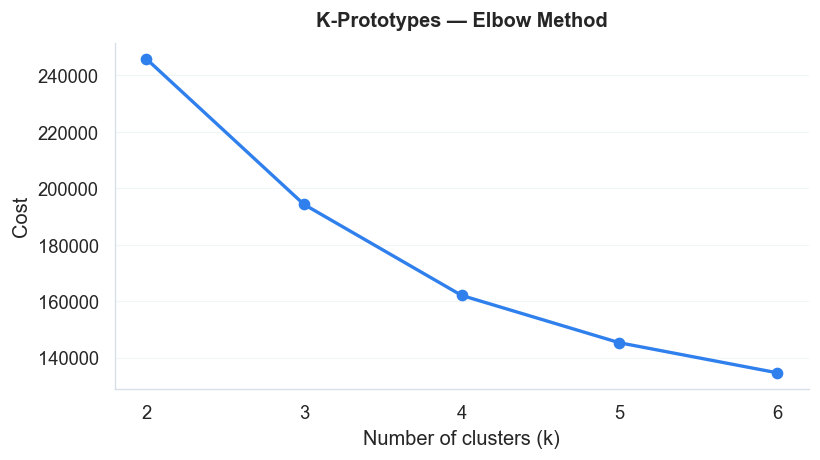

In [41]:
# ── Find best k using elbow method ───────────────────────────────────────────
# Note: K-Prototypes is slow, so we try fewer values
K_VALUES_KP = [2, 3, 4, 5, 6]

costs = []
X_kproto = df_kproto.values  # K-Prototypes needs numpy array

for k in K_VALUES_KP:
    print(f"Fitting k={k}...")
    kp = KPrototypes(n_clusters=k, random_state=RANDOM_STATE, n_init=5)
    kp.fit(X_kproto, categorical=cat_indices)
    costs.append(kp.cost_)
    print(f"  cost={kp.cost_:.0f}")

plt.figure(figsize=(7, 4))
plt.plot(K_VALUES_KP, costs, marker="o", color=PLOT_COLORS["neutral"], linewidth=2)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Cost")
plt.title("K-Prototypes — Elbow Method")
plt.xticks(K_VALUES_KP)
polish_axes(plt.gca())
plt.tight_layout()
plt.show()


The elbow curve shows a gradual decrease with no sharp bend, consistent with the 
pattern observed in K-Means. The most visible inflection occurs around k=4, which 
we adopt for consistency with the previous clustering analyses and to allow direct 
comparison of the resulting groups.

In [42]:
# ── Fit final K-Prototypes with k=4 ─────────────────────────────────────────
kp_final = KPrototypes(n_clusters=4, random_state=RANDOM_STATE, n_init=5)
kp_labels = kp_final.fit_predict(X_kproto, categorical=cat_indices)

kproto_df = df_kproto.copy()
kproto_df["cluster"] = kp_labels
kproto_df["income"] = y.values

# ── 1. Cluster sizes and income proportion ────────────────────────────────────
summary = kproto_df.groupby("cluster").agg(
    size=("income", "count"),
    income_prop=("income", "mean")
).round(3)
summary.index = [f"Cluster {i}" for i in range(4)]
summary.loc["Global"] = [len(kproto_df), y.mean().round(3)]
print("Cluster summary:")
display(summary)

# ── 2. Numeric means per cluster ──────────────────────────────────────────────
cluster_means = kproto_df.groupby("cluster")[num_col_names].mean().round(3)
cluster_means.loc["Global"] = kproto_df[num_col_names].mean().round(3)
cluster_means.index = [f"Cluster {i}" for i in range(4)] + ["Global"]
print("\nNumeric means per cluster:")
display(cluster_means)

# ── 3. Categorical mode per cluster ──────────────────────────────────────────
cat_original = list(cat_reconstruct.keys())
cluster_modes = kproto_df.groupby("cluster")[cat_original].agg(
    lambda x: x.value_counts().index[0]
)
cluster_modes.index = [f"Cluster {i}" for i in range(4)]
print("\nMost frequent category per cluster:")
display(cluster_modes)

Cluster summary:


,size,income_prop
Cluster 0,14563.0,0.315
Cluster 1,2634.0,0.637
Cluster 2,1519.0,0.509
Cluster 3,13845.0,0.058
Global,32561.0,0.241



Numeric means per cluster:


,num__age,num__education_num,num__hours_per_week,num__capital_gain_log,num__capital_loss_log,num__net_capital,num__age_x_hours
Cluster 0,0.622,0.075,0.375,-0.300,-0.223,-0.204,0.672
Cluster 1,0.440,0.409,0.293,3.318,-0.223,2.686,0.500
Cluster 2,0.232,0.345,0.230,-0.301,4.486,-0.889,0.331
Cluster 3,-0.755,-0.194,-0.473,-0.287,-0.223,-0.203,-0.828
Global,0.004,0.000,0.001,-0.002,-0.003,-0.002,0.004



Most frequent category per cluster:


,workclass,education,marital_status,occupation,relationship,race,capital_direction
Cluster 0,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Exec-managerial,relationship_Husband,race_White,capital_direction_none
Cluster 1,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Prof-specialty,relationship_Husband,race_White,capital_direction_gain
Cluster 2,workclass_Private,education_HS-grad,marital_status_Married-civ-spouse,occupation_Exec-managerial,relationship_Husband,race_White,capital_direction_loss
Cluster 3,workclass_Private,education_HS-grad,marital_status_Never-married,occupation_Other-service,relationship_Own-child,race_White,capital_direction_none


The K-Prototypes clustering with k=4 recovers a structure remarkably consistent with 
K-Means, despite incorporating categorical variables directly. The four clusters map 
almost exactly onto the K-Means groups:

- **Cluster 3** (6% >50K, n=13,845) — *Young single low-income workers*: youngest, 
fewest hours, lowest age_x_hours. Mode categories confirm: never-married, own-child 
relationship, service occupation. Identical to K-Means Cluster 3.

- **Cluster 0** (32% >50K, n=14,563) — *Older working-class married men*: older, 
more hours, no capital activity. Mode: married, husband, private sector, HS-grad, 
exec-managerial occupation. Matches K-Means Cluster 0.

- **Cluster 2** (51% >50K, n=1,519) — *Financially active, capital losses*: 
identical in both size and numeric profile to K-Means Cluster 2. Mode confirms 
married, husband, private sector, capital direction loss.

- **Cluster 1** (64% >50K, n=2,634) — *Capital-wealthy professionals*: high capital 
gains, high net capital, most educated. Mode: married husband, Prof-specialty 
occupation, capital direction gain. Matches K-Means Cluster 1.

The strong consistency between K-Means and K-Prototypes is the key finding here: 
adding categorical variables directly does not meaningfully change the cluster 
structure. This suggests that the continuous features — particularly capital activity 
and age — are the primary drivers of the natural groupings in this dataset, and that 
the categorical variables are largely aligned with those same groupings rather than 
introducing independent structure. This also retrospectively validates our decision 
to run K-Means and GMM on continuous features only.

## Unsupervised Analysis — Summary

The three clustering approaches (K-Means, GMM, and K-Prototypes) and the PCA 
analysis converge on a consistent picture of the data's natural structure.

**PCA** revealed that the continuous features carry largely independent information, 
requiring 4 components to explain 80% of variance. The first component — driven by 
age, work hours and capital gains — shows a clear gradient with income even though 
it was constructed without the label. Notably, the directions of maximum variance do 
not always coincide with the most discriminative directions, as illustrated by the 
PC3 vs PC4 plot showing clearer income separation despite lower explained variance.

**K-Means (k=4)** identified four socioeconomically meaningful groups with a clear 
income gradient: young single low-income workers (8% >50K), older working-class 
married men (31%), financially active individuals with capital losses (51%), and 
capital-wealthy professionals (64%). Capital activity emerged as the strongest 
differentiator of high income, more so than age or education in isolation.

**GMM (full, n=6)** confirmed the K-Means structure while providing finer granularity 
within the low-to-moderate income population, splitting it into part-time young 
workers, baseline full-time workers, hardworking moderate-income employees, and 
near-retirement individuals. The two capital activity clusters were recovered almost 
identically.

**K-Prototypes** incorporated categorical variables directly and produced a cluster 
structure nearly identical to K-Means, confirming that the continuous features are 
the primary drivers of natural groupings in this dataset and retrospectively 
validating the choice to run K-Means and GMM on continuous features only.

Overall, the unsupervised analysis suggests that income in this dataset is primarily 
stratified along two axes: capital activity (gains or losses) and the combination of 
age and work hours. Categorical variables such as marital status, occupation and 
relationship are strongly aligned with these axes but do not introduce independent 
cluster structure. These findings provide a useful foundation for the supervised 
modeling phases that follow.